# Survival Analysis: Right-Censored Trial Follow-Up with KM, Log-Rank, Cox, and Discrete-Time Hazard

**The problem.** Time-to-event outcomes — overall survival, progression-free survival, time-to-relapse — are the backbone of oncology and chronic-disease trial evidence. They are also the hardest outcomes to model honestly, because the majority of patients are *censored*: they leave follow-up, withdraw, or the study ends before their event occurs. Pretending those patients didn't exist biases every estimate. The question this notebook answers: **given a right-censored trial cohort, is there a statistically and clinically meaningful treatment effect, how large is it, which covariates drive residual risk, and does the effect hold up across subgroups and over time?**

**The approach.** On a simulated 4,200-patient trial with a proportional-hazards data-generating mechanism, random loss-to-follow-up censoring, and a 30-month horizon:

1. **Kaplan-Meier** survival curves by arm — the canonical visual.
2. **Restricted Mean Survival Time (RMST)** — an interpretable effect size in months of survival gained, robust when proportional hazards is questionable.
3. **Log-rank test** for arm-level statistical significance.
4. **Cox proportional hazards** model via partial likelihood — covariate-adjusted hazard ratios.
5. **Discrete-time hazard** model (person-period logistic) for patient-level dynamic risk and month-by-month hazard trajectories.
6. **Subgroup RMST** consistency — because a pooled effect can hide heterogeneity that matters for labelling and patient selection.

**Audience.** Biostatisticians, clinical epidemiologists, HEOR teams, and medical reviewers preparing or defending survival evidence.

## 0. Setup and reproducibility

All randomness is seeded so simulated event times, censoring, KM curves, Cox coefficients, and subgroup RMST values are identical across runs.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.optimize import minimize
from scipy.stats import chi2
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

np.random.seed(321)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

C:\Users\diogo\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\diogo\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## 1. Simulating a right-censored trial follow-up

We generate a proportional-hazards cohort with a treatment effect of HR ≈ exp(−0.42) ≈ 0.66 (a 34% reduction in hazard on treatment) and uniform loss-to-follow-up between months 6 and 30. Observed time is the minimum of true event time and censor time; `event = 1` only if the event occurred before censoring. This is exactly the data shape a trial registry hands to a biostatistician.

In [2]:
n = 4200
max_follow = 30  # months

df = pd.DataFrame(
    {
        "age": np.random.randint(30, 86, size=n),
        "sex": np.random.choice(["F", "M"], size=n),
        "biomarker": np.random.normal(0.0, 1.0, size=n),
        "comorbidity": np.random.poisson(1.5, size=n),
        "baseline_severity": np.clip(np.random.normal(5.0, 1.4, size=n), 0.2, 10.0),
        "region": np.random.choice(["NA", "EU", "APAC", "LATAM"], p=[0.40, 0.30, 0.20, 0.10], size=n),
        "arm": np.random.choice(["control", "treatment"], p=[0.5, 0.5], size=n),
    }
)

df["elderly"] = (df["age"] >= 65).astype(int)

# proportional hazards data-generating mechanism
linpred = (
    0.017 * (df["age"].to_numpy() - 55)
    + 0.34 * df["biomarker"].to_numpy()
    + 0.23 * df["comorbidity"].to_numpy()
    + 0.11 * df["baseline_severity"].to_numpy()
    - 0.42 * (df["arm"].to_numpy() == "treatment")
    + np.where(df["region"].to_numpy() == "LATAM", 0.09, 0.0)
)

base_hazard = 0.03
hazard = base_hazard * np.exp(linpred)

true_event_time = np.random.exponential(scale=1 / hazard)
loss_to_followup = np.random.uniform(6, max_follow, size=n)

obs_time = np.minimum(true_event_time, loss_to_followup)
event = (true_event_time <= loss_to_followup).astype(int)

df["time"] = np.clip(np.ceil(obs_time), 1, max_follow).astype(int)
df["event"] = event

df.head()

,age,sex,biomarker,comorbidity,baseline_severity,region,arm,elderly,time,event
0,82,F,-0.626592,1,6.264388,NA,treatment,1,9,0
1,56,M,-0.672602,2,4.599696,NA,control,0,21,0
2,61,M,-0.189821,1,5.008881,NA,control,0,25,0
3,71,F,1.181544,1,5.974823,NA,control,1,11,1
4,38,M,0.104851,0,5.270785,NA,control,0,14,1


In [3]:
summary = pd.Series(
    {
        "n_patients": len(df),
        "event_rate": df["event"].mean(),
        "median_observed_time": df["time"].median(),
        "treatment_share": (df["arm"] == "treatment").mean(),
    }
)
summary

n_patients              4200.000000
event_rate                 0.632143
median_observed_time       9.000000
treatment_share            0.490952
dtype: float64

## 2. Kaplan-Meier estimator

The Kaplan-Meier estimator is the non-parametric survival curve: at each observed event time it updates *S(t)* by the conditional probability of surviving that instant, using the count of patients still at risk. Critically, it handles censoring correctly — censored patients contribute to the at-risk set up to their censor time and then exit without counting as an event. The curves by arm are the first visual of treatment effect any reviewer looks at.

In [4]:
def kaplan_meier(times: np.ndarray, events: np.ndarray, t_max: int):
    km = []
    s = 1.0
    at_risk = len(times)

    for t in range(1, t_max + 1):
        d_t = int(((times == t) & (events == 1)).sum())
        c_t = int(((times == t) & (events == 0)).sum())

        if at_risk > 0:
            s *= (1 - d_t / at_risk)

        km.append({"t": t, "survival": s, "n_risk": at_risk, "d": d_t, "c": c_t})
        at_risk -= (d_t + c_t)

    return pd.DataFrame(km)

km_ctrl = kaplan_meier(
    df.loc[df["arm"] == "control", "time"].to_numpy(),
    df.loc[df["arm"] == "control", "event"].to_numpy(),
    max_follow,
)

km_trt = kaplan_meier(
    df.loc[df["arm"] == "treatment", "time"].to_numpy(),
    df.loc[df["arm"] == "treatment", "event"].to_numpy(),
    max_follow,
)

km_ctrl.head(), km_trt.head()

(   t  survival  n_risk    d  c
 0  1  0.916277    2138  179  0
 1  2  0.833489    1959  177  0
 2  3  0.769411    1782  137  0
 3  4  0.702058    1645  144  0
 4  5  0.647802    1501  116  0,
    t  survival  n_risk    d  c
 0  1  0.938894    2062  126  0
 1  2  0.885548    1936  110  0
 2  3  0.842871    1826   88  0
 3  4  0.797284    1738   94  0
 4  5  0.760912    1644   75  0)

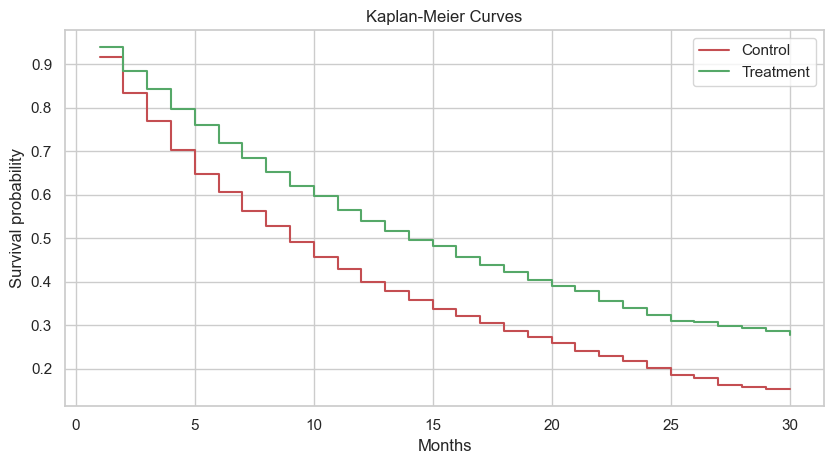

In [5]:
plt.figure(figsize=(8.5, 4.8))
plt.step(km_ctrl["t"], km_ctrl["survival"], where="post", label="Control", color="#C44E52")
plt.step(km_trt["t"], km_trt["survival"], where="post", label="Treatment", color="#55A868")
plt.title("Kaplan-Meier Curves")
plt.xlabel("Months")
plt.ylabel("Survival probability")
plt.legend()
plt.tight_layout()
plt.show()

**What to read here.** A persistent gap between the two step functions, with treatment above control at every time point, is the visual signature of treatment benefit. The magnitude of the gap at study end is the absolute survival-rate improvement; the integrated area between curves is proportional to RMST difference (computed explicitly below). If curves cross, the proportional-hazards assumption is suspect and Cox HRs should be interpreted with care — RMST is still safe because it makes no PH assumption.

## 3. Restricted Mean Survival Time (RMST)

Median survival is the classical summary, but it is undefined when fewer than half of patients experience the event — common in early-line oncology and any setting with strong treatment effect. **RMST up to horizon τ** — the area under the KM curve from 0 to τ — is always defined, lives in interpretable units (months of survival), and provides a legitimate effect-size comparison even when proportional hazards fails. RMST difference between arms is the headline number HEOR teams increasingly prefer.

In [6]:
def rmst_from_km(km_df: pd.DataFrame, tau: int):
    # Piecewise-constant survival integration
    times = np.concatenate(([0], km_df["t"].to_numpy()))
    surv = np.concatenate(([1.0], km_df["survival"].to_numpy()))

    area = 0.0
    for i in range(len(times) - 1):
        dt = min(times[i + 1], tau) - times[i]
        if dt > 0:
            area += surv[i] * dt
    return area

rmst_ctrl = rmst_from_km(km_ctrl, max_follow)
rmst_trt = rmst_from_km(km_trt, max_follow)
rmst_diff = rmst_trt - rmst_ctrl

pd.Series({"rmst_control": rmst_ctrl, "rmst_treatment": rmst_trt, "rmst_diff_treatment_minus_control": rmst_diff})

rmst_control                         12.595903
rmst_treatment                       16.107853
rmst_diff_treatment_minus_control     3.511951
dtype: float64

## 4. Log-rank test

The log-rank test is the workhorse significance test for survival differences between two groups. At each observed event time it compares observed deaths in arm 1 to what would be expected under the null of equal hazards, accumulates the standardised difference across time, and converts it to a chi-square on 1 degree of freedom. It has maximum power under proportional hazards — one more reason to sanity-check PH before relying on it.

In [7]:
def logrank_test(data: pd.DataFrame, group_col="arm", time_col="time", event_col="event"):
    gvals = data[group_col].unique()
    g1, g2 = gvals[0], gvals[1]
    x = data[data[group_col] == g1]
    y = data[data[group_col] == g2]

    O1 = E1 = V1 = 0.0

    for t in sorted(data[time_col].unique()):
        n1 = (x[time_col] >= t).sum()
        n2 = (y[time_col] >= t).sum()
        n = n1 + n2
        if n <= 1:
            continue

        d1 = ((x[time_col] == t) & (x[event_col] == 1)).sum()
        d2 = ((y[time_col] == t) & (y[event_col] == 1)).sum()
        d = d1 + d2
        if d == 0:
            continue

        e1 = d * (n1 / n)
        v1 = (n1 * n2 * d * (n - d)) / (n**2 * (n - 1)) if n > 1 else 0.0

        O1 += d1
        E1 += e1
        V1 += v1

    chi_sq = ((O1 - E1) ** 2) / max(V1, 1e-12)
    p_val = 1 - chi2.cdf(chi_sq, df=1)
    return chi_sq, p_val

logrank_chi2, logrank_p = logrank_test(df)
pd.Series({"logrank_chi2": logrank_chi2, "p_value": logrank_p})

logrank_chi2    99.545262
p_value          0.000000
dtype: float64

**What to read here.** A p-value below the pre-specified alpha (typically 0.05, or a pre-specified stricter threshold under group-sequential designs) rejects the null of no treatment effect. The chi-square magnitude is the strength of evidence against the null — useful context when reporting alongside confidence intervals. Statistical significance is *necessary* but not *sufficient* for clinical significance; pair the p-value with RMST difference for a full picture.

## 5. Cox proportional hazards (manual partial likelihood)

The Cox model estimates covariate effects on the **hazard** — the instantaneous event rate — without needing to specify a baseline hazard shape. Coefficients are log hazard ratios; `exp(β)` is the multiplicative effect on risk per unit increase in the covariate. We fit via Breslow partial likelihood with BFGS to keep the implementation transparent — every step is visible, rather than hidden behind `lifelines`.

In [8]:
cox_df = df.copy()
cox_df["arm_treat"] = (cox_df["arm"] == "treatment").astype(int)
cox_df["sex_m"] = (cox_df["sex"] == "M").astype(int)

cox_features = ["arm_treat", "age", "biomarker", "comorbidity", "baseline_severity", "elderly", "sex_m"]
X = cox_df[cox_features].to_numpy(dtype=float)
T = cox_df["time"].to_numpy(dtype=float)
E = cox_df["event"].to_numpy(dtype=int)

# Standardize continuous columns for numerical stability
cont_idx = [1, 2, 3, 4]
X_std = X.copy()
for j in cont_idx:
    mu = X[:, j].mean()
    sd = X[:, j].std(ddof=1)
    X_std[:, j] = (X[:, j] - mu) / (sd + 1e-12)

order = np.argsort(T)
Xo = X_std[order]
To = T[order]
Eo = E[order]


def neg_log_partial_lik(beta):
    xb = Xo @ beta
    nll = 0.0
    for i in range(len(To)):
        if Eo[i] == 1:
            risk = To >= To[i]
            denom = np.log(np.sum(np.exp(xb[risk])))
            nll -= xb[i] - denom
    return nll

init = np.zeros(Xo.shape[1])
res = minimize(neg_log_partial_lik, init, method="BFGS")
beta_hat = res.x

hazard_ratios = pd.DataFrame({
    "feature": cox_features,
    "beta": beta_hat,
    "hazard_ratio": np.exp(beta_hat),
}).sort_values("hazard_ratio", ascending=False)

hazard_ratios

,feature,beta,hazard_ratio
2,biomarker,0.351899,1.421765
3,comorbidity,0.288566,1.334512
1,age,0.217315,1.242735
4,baseline_severity,0.144737,1.155736
5,elderly,0.087796,1.091765
6,sex_m,-0.067805,0.934442
0,arm_treat,-0.405079,0.666924


**What to read here.** `arm_treat` should carry a hazard ratio below 1 — the protective effect built into the simulation. Covariates with HR > 1 (biomarker, comorbidity, age, baseline severity in this cohort) increase instantaneous event risk; the higher the HR, the steeper the effect. Standardised continuous covariates mean the HR reported is per standard-deviation change, which makes them directly comparable in magnitude rather than being scaled by the arbitrary units of each feature.

## 6. Discrete-time hazard model (person-period)

Cox gives a population-level hazard ratio; a clinical decision support tool needs **patient-level, month-by-month risk**. We expand the cohort into person-period format (one row per patient per month they are still at risk) and fit a logistic regression for the event indicator at each month. The output is a flexible discrete-time hazard function — good enough for risk-stratified monitoring schedules without needing a full parametric survival model.

In [9]:
rows = []
for _, r in df.iterrows():
    for t in range(1, int(r["time"]) + 1):
        rows.append(
            {
                "age": r["age"],
                "sex": r["sex"],
                "biomarker": r["biomarker"],
                "comorbidity": r["comorbidity"],
                "baseline_severity": r["baseline_severity"],
                "elderly": r["elderly"],
                "region": r["region"],
                "arm": r["arm"],
                "time_bin": t,
                "event_t": int((t == r["time"]) and (r["event"] == 1)),
            }
        )

pp = pd.DataFrame(rows)
pp.head()

,age,sex,biomarker,comorbidity,baseline_severity,elderly,region,arm,time_bin,event_t
0,82,F,-0.626592,1,6.264388,1,NA,treatment,1,0
1,82,F,-0.626592,1,6.264388,1,NA,treatment,2,0
2,82,F,-0.626592,1,6.264388,1,NA,treatment,3,0
3,82,F,-0.626592,1,6.264388,1,NA,treatment,4,0
4,82,F,-0.626592,1,6.264388,1,NA,treatment,5,0


In [10]:
haz_features = [
    "age",
    "sex",
    "biomarker",
    "comorbidity",
    "baseline_severity",
    "elderly",
    "region",
    "arm",
    "time_bin",
]

Xh = pp[haz_features]
yh = pp["event_t"]

num_cols = ["age", "biomarker", "comorbidity", "baseline_severity", "elderly", "time_bin"]
cat_cols = ["sex", "region", "arm"]

X_train, X_test, y_train, y_test = train_test_split(
    Xh, yh, test_size=0.30, random_state=321, stratify=yh
)

haz_model = Pipeline(
    steps=[
        (
            "prep",
            ColumnTransformer(
                [
                    ("num", StandardScaler(), num_cols),
                    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
                ]
            ),
        ),
        ("clf", LogisticRegression(max_iter=500, random_state=321)),
    ]
)

haz_model.fit(X_train, y_train)
phat = haz_model.predict_proba(X_test)[:, 1]

pd.Series(
    {
        "event_prevalence_person_period": yh.mean(),
        "hazard_model_auc": roc_auc_score(y_test, phat),
    }
)

event_prevalence_person_period    0.058577
hazard_model_auc                  0.678494
dtype: float64

## 7. Dynamic risk trajectories by arm

With the discrete-time model we can plot predicted monthly hazard for an average-patient profile in each arm, exposing when treatment benefit actually kicks in and how it evolves over follow-up. A flat trajectory means no time-varying structure; a widening or narrowing gap signals the treatment effect strengthens or wanes — information a survival curve summarises away.

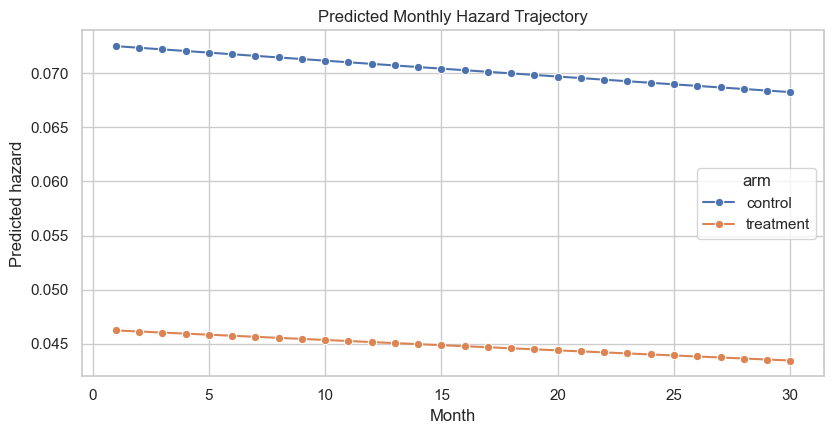

In [11]:
# Predict average hazard by month for each arm using average patient profile
profile_base = {
    "age": float(df["age"].mean()),
    "sex": "F",
    "biomarker": float(df["biomarker"].mean()),
    "comorbidity": float(df["comorbidity"].mean()),
    "baseline_severity": float(df["baseline_severity"].mean()),
    "elderly": 0,
    "region": "NA",
}

traj_rows = []
for arm in ["control", "treatment"]:
    for t in range(1, max_follow + 1):
        row = profile_base.copy()
        row.update({"arm": arm, "time_bin": t})
        q = pd.DataFrame([row])
        hz = haz_model.predict_proba(q[haz_features])[:, 1][0]
        traj_rows.append({"arm": arm, "month": t, "pred_hazard": hz})

traj = pd.DataFrame(traj_rows)

plt.figure(figsize=(8.5, 4.5))
sns.lineplot(data=traj, x="month", y="pred_hazard", hue="arm", marker="o")
plt.title("Predicted Monthly Hazard Trajectory")
plt.xlabel("Month")
plt.ylabel("Predicted hazard")
plt.tight_layout()
plt.show()

**What to read here.** The control line should sit consistently above the treatment line — that is the treatment effect expressed as a hazard gap over time. A constant gap supports the proportional-hazards assumption Cox relies on; a widening gap suggests the benefit grows with exposure (a delayed effect); a narrowing gap suggests the benefit wears off. Any of these shapes has direct implications for trial endpoint timing and for real-world adherence strategy.

## 8. Subgroup consistency checks

A pooled RMST difference can hide heterogeneity that matters for labelling, eligibility, and patient-level recommendation. We recompute RMST by arm within each key subgroup (sex, elderly status) and report the treatment-minus-control gain separately. A consistent positive difference across subgroups supports a broad label; material negative or null differences in any subgroup warrant either a restricted label or an explicit discussion in the clinical narrative.

In [12]:
def rmst_by_subset(data: pd.DataFrame, label: str):
    k_ctrl = kaplan_meier(
        data.loc[data["arm"] == "control", "time"].to_numpy(),
        data.loc[data["arm"] == "control", "event"].to_numpy(),
        max_follow,
    )
    k_trt = kaplan_meier(
        data.loc[data["arm"] == "treatment", "time"].to_numpy(),
        data.loc[data["arm"] == "treatment", "event"].to_numpy(),
        max_follow,
    )
    return {
        "subset": label,
        "n": len(data),
        "rmst_control": rmst_from_km(k_ctrl, max_follow),
        "rmst_treatment": rmst_from_km(k_trt, max_follow),
        "rmst_diff": rmst_from_km(k_trt, max_follow) - rmst_from_km(k_ctrl, max_follow),
    }

subsets = []
for grp in ["F", "M"]:
    subsets.append(rmst_by_subset(df[df["sex"] == grp], f"sex={grp}"))

for grp in [0, 1]:
    subsets.append(rmst_by_subset(df[df["elderly"] == grp], f"elderly={grp}"))

subgroup_rmst = pd.DataFrame(subsets)
subgroup_rmst

,subset,n,rmst_control,rmst_treatment,rmst_diff
0,sex=F,2045,12.307445,15.706557,3.399112
1,sex=M,2155,12.870587,16.482595,3.612008
2,elderly=0,2627,14.023232,17.520252,3.497020
3,elderly=1,1573,10.215622,13.804215,3.588593


C:\Users\diogo\AppData\Local\Temp\ipykernel_13860\278880123.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subgroup_rmst, x="subset", y="rmst_diff", palette="mako")


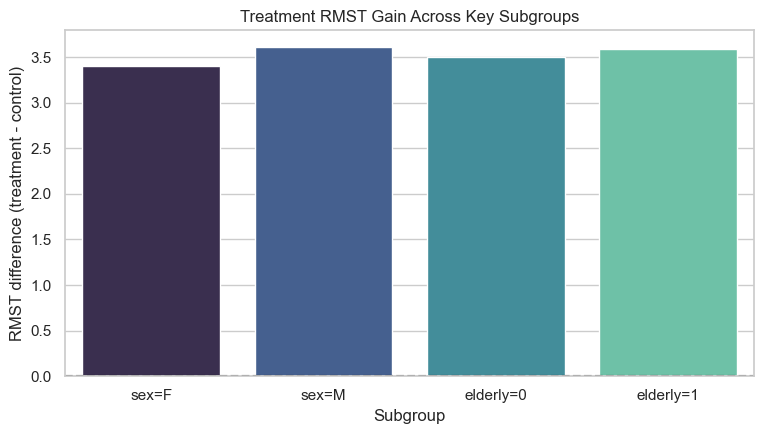

In [13]:
plt.figure(figsize=(7.8, 4.5))
sns.barplot(data=subgroup_rmst, x="subset", y="rmst_diff", palette="mako")
plt.axhline(0.0, linestyle="--", color="black")
plt.title("Treatment RMST Gain Across Key Subgroups")
plt.xlabel("Subgroup")
plt.ylabel("RMST difference (treatment - control)")
plt.tight_layout()
plt.show()

**What to read here.** Bars consistently above the zero line support a broad label — treatment helps across subgroups. A dropped or negative bar in any subgroup is a heterogeneity signal that must be carried forward into the clinical narrative, the protocol (e.g. stratification at randomisation), or the label (e.g. contra-indication or restricted indication). Non-overlapping confidence intervals would strengthen this read — adding them is a natural production extension.

## 9. Takeaways, limitations, and what a production version would add

**Takeaways**

- KM + RMST + log-rank gives a complete arm-level view: the picture, the effect size in interpretable units, and the statistical test — each answering a different question.
- Cox PH turns population evidence into covariate-adjusted hazard ratios usable for covariate-controlled inference and patient-level risk scoring.
- Discrete-time hazard on person-period data is a pragmatic alternative for dynamic, time-varying risk trajectories without the modelling overhead of a full parametric survival model.
- Subgroup RMST is the honest heterogeneity check — a pooled hazard ratio can look great while a key subgroup sees no benefit.

**Limitations**

- Event times are simulated exponential with a proportional-hazards mechanism; real-world hazards are rarely this clean and PH is often violated (cross-over designs, delayed effects, immunotherapy trials). Always diagnose PH (e.g. Schoenfeld residuals) before relying on Cox.
- Censoring here is uniform and independent of event risk. Informative censoring (patients leaving *because* they are sicker) biases every estimator — production analyses need sensitivity analyses that stress this assumption.
- The Cox implementation is Breslow ties; Efron is standard in most packages and is closer to the exact partial likelihood.
- Confidence intervals on KM survival, RMST difference, and hazard ratios are not produced here. All three have standard asymptotic formulas or bootstrap procedures that a production pipeline must include.

**What a production version would add**

- **Schoenfeld residual tests** for the PH assumption, with stratified Cox fallbacks where PH fails.
- **Confidence intervals everywhere** — Greenwood SE on KM, variance estimators on RMST and its difference, Wald CIs on HRs.
- **Competing-risks extension** (Fine-Gray sub-distribution hazards) when non-target events (death from other causes) should not be treated as censoring.
- **Landmark analysis** for post-baseline treatment variation and time-varying covariates.
- **Sensitivity analyses** to informative censoring (tipping-point or pattern-mixture).